In [1]:
from qecdec.experiments import HexColorCode_Phenom_Memory

In [2]:
d = 3
expmt = HexColorCode_Phenom_Memory(
    d=d, rounds=d, basis="Y", depolarizing_error_rate=0.001, meas_error_rate=0.005
)

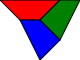

In [3]:
def draw_tiles(expmt: HexColorCode_Phenom_Memory, scaling: float = 20):
    import drawsvg as draw

    tiles = expmt.tiles
    width = max(v.real for t in tiles for v in t.vertices) * scaling
    height = max(v.imag for t in tiles for v in t.vertices) * scaling

    d = draw.Drawing(width, height)

    colors = ["red", "green", "blue"]

    for t in tiles:
        p = draw.Path(fill=colors[t.color], stroke="black")
        p.M(t.vertices[0].real * scaling, t.vertices[0].imag * scaling)
        for v in t.vertices[1:]:
            p.L(v.real * scaling, v.imag * scaling)
        p.Z()
        d.append(p)

    return d


draw_tiles(expmt)

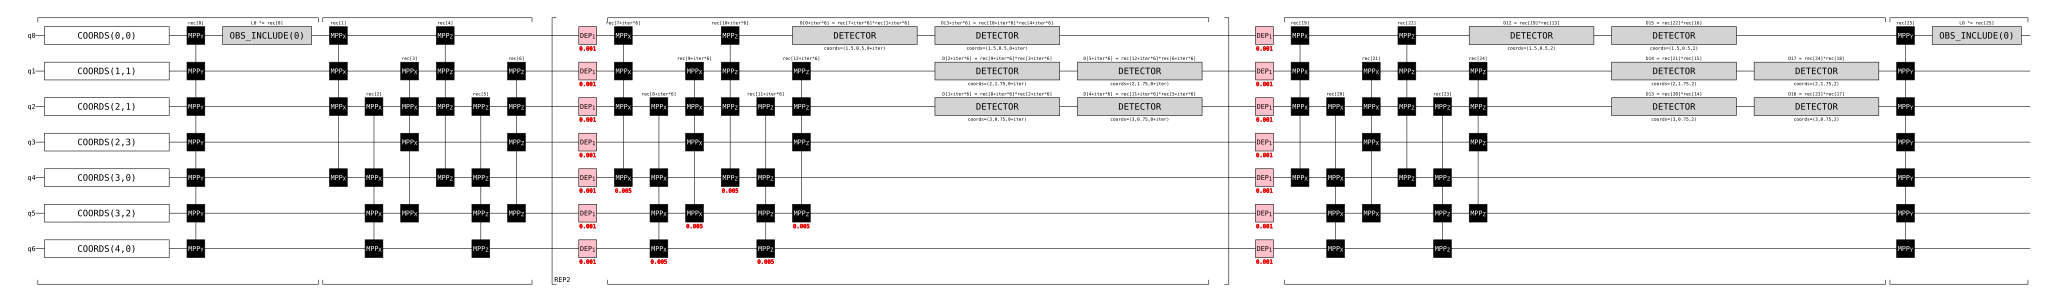

In [4]:
fig = expmt.circuit.diagram("timeline")
fig

In [ ]:
expmt.dem.diagram("matchgraph-3d-html")

<!DOCTYPE html>
<html>
<head>
  <meta charset="UTF-8" />
  <script type="importmap">
    {
      "imports": {
        "three": "https://unpkg.com/three@0.138.0/build/three.module.js",
        "three-orbitcontrols": "https://unpkg.com/three@0.138.0/examples/jsm/controls/OrbitControls.js",
        "three-gltf-loader": "https://unpkg.com/three@0.138.0/examples/jsm/loaders/GLTFLoader.js"
      }
    }
  </script>
</head>
<body>
  <a download="model.gltf" id="stim-3d-viewer-download-link" href="data:text/plain;base64,eyJhY2Nlc3NvcnMiOlt7ImJ1ZmZlclZpZXciOjAsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLDAuNDAwMDAwMDA1OTYwNDY0LDAuNDAwMDAwMDA1OTYwNDY0XSwibWluIjpbMCwtMC40MDAwMDAwMDU5NjA0NjQsLTAuNDAwMDAwMDA1OTYwNDY0XSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjEsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLjQwMDAwMDAwNTk2MDQ2NCwwLDAuNDAwMDAwMDA1OTYwNDY0XSwibWluIjpbLTAuNDAwMDAwMDA1OTYwNDY0LDAsLTAuNDAwMDAwMDA1OTYwNDY0XSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjIsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo5LCJtYXgiOlswLjQwMDAwMDAwNTk2MDQ2NCwwLjQwMDAwMDAwNTk2MDQ2NCwwXSwibWluIjpbLTAuNDAwMDAwMDA1OTYwNDY0LC0wLjQwMDAwMDAwNTk2MDQ2NCwwXSwibmFtZSI6ImNpcmNsZV9sb29wIiwidHlwZSI6IlZFQzMifSx7ImJ1ZmZlclZpZXciOjMsImJ5dGVPZmZzZXQiOjAsImNvbXBvbmVudFR5cGUiOjUxMjYsImNvdW50Ijo0MiwibWF4IjpbOSw1LjI1LDZdLCJtaW4iOls0LjUsMS41LDBdLCJuYW1lIjoiYnVmX3NjYXR0ZXJlZF9saW5lcyIsInR5cGUiOiJWRUMzIn0seyJidWZmZXJWaWV3Ijo0LCJieXRlT2Zmc2V0IjowLCJjb21wb25lbnRUeXBlIjo1MTI2LCJjb3VudCI6NzIsIm1heCI6WzE3Ljk0NDI3MTA4NzY0NjUsMTQuNTM0NzY3MTUwODc4OSwxNC4yOTU2MTMyODg4Nzk0XSwibWluIjpbLTMuMTgyMjEyODI5NTg5ODQsLTQuOTAxODQ0MDI0NjU4MiwtOC4yOTU2MTMyODg4NzkzOV0sIm5hbWUiOiJidWZfcmVkX3NjYXR0ZXJlZF9saW5lcyIsInR5cGUiOiJWRUMzIn0seyJidWZmZXJWaWV3Ijo1LCJieXRlT2Zmc2V0IjowLCJjb21wb25lbnRUeXBlIjo1MTI2LCJjb3VudCI6MTA4LCJtYXgiOls5LDUuMjUsNl0sIm1pbiI6WzQuNSwxLjUsMF0sIm5hbWUiOiJidWZfYmx1ZV9zY2F0dGVyZWRfbGluZXMiLCJ0eXBlIjoiVkVDMyJ9LHsiYnVmZmVyVmlldyI6NiwiYnl0ZU9mZnNldCI6MCwiY29tcG9uZW50VHlwZSI6NTEyNiwiY291bnQiOjM2LCJtYXgiOls5LDUuMjUsNl0sIm1pbiI6WzQuNSwxLjUsMF0sIm5hbWUiOiJidWZfcHVycGxlX3NjYXR0ZXJlZF9saW5lcyIsInR5cGUiOiJWRUMzIn1dLCJhc3NldCI6eyJ2ZXJzaW9uIjoiMi4wIn0sImJ1ZmZlclZpZXdzIjpbeyJidWZmZXIiOjAsImJ5dGVMZW5ndGgiOjEwOCwiYnl0ZU9mZnNldCI6MCwibmFtZSI6ImNpcmNsZV9sb29wIiwidGFyZ2V0IjozNDk2Mn0seyJidWZmZXIiOjEsImJ5dGVMZW5ndGgiOjEwOCwiYnl0ZU9mZnNldCI6MCwibmFtZSI6ImNpcmNsZV9sb29wIiwidGFyZ2V0IjozNDk2Mn0seyJidWZmZXIiOjIsImJ5dGVMZW5ndGgiOjEwOCwiYnl0ZU9mZnNldCI6MCwibmFtZSI6ImNpcmNsZV9sb29wIiwidGFyZ2V0IjozNDk2Mn0seyJidWZmZXIiOjMsImJ5dGVMZW5ndGgiOjUwNCwiYnl0ZU9mZnNldCI6MCwibmFtZSI6ImJ1Zl9zY2F0dGVyZWRfbGluZXMiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6NCwiYnl0ZUxlbmd0aCI6ODY0LCJieXRlT2Zmc2V0IjowLCJuYW1lIjoiYnVmX3JlZF9zY2F0dGVyZWRfbGluZXMiLCJ0YXJnZXQiOjM0OTYyfSx7ImJ1ZmZlciI6NSwiYnl0ZUxlbmd0aCI6MTI5NiwiYnl0ZU9mZnNldCI6MCwibmFtZSI6ImJ1Zl9ibHVlX3NjYXR0ZXJlZF9saW5lcyIsInRhcmdldCI6MzQ5NjJ9LHsiYnVmZmVyIjo2LCJieXRlTGVuZ3RoIjo0MzIsImJ5dGVPZmZzZXQiOjAsIm5hbWUiOiJidWZfcHVycGxlX3NjYXR0ZXJlZF9saW5lcyIsInRhcmdldCI6MzQ5NjJ9XSwiYnVmZmVycyI6W3siYnl0ZUxlbmd0aCI6MTA4LCJuYW1lIjoiY2lyY2xlX2xvb3AiLCJ1cmkiOiJkYXRhOmFwcGxpY2F0aW9uL29jdGV0LXN0cmVhbTtiYXNlNjQsQUFBQUFNM016RDRBQUFBQUFBQUFBTVBRa0Q3RDBKQStBQUFBQVBJd2xyTE56TXcrQUFBQUFNUFFrTDdEMEpBK0FBQUFBTTNNekw3eU1CYXpBQUFBQU1IUWtMN0UwSkMrQUFBQUFQTGtvekhOek15K0FBQUFBTWJRa0Q2LzBKQytBQUFBQU0zTXpENEFBQUFBIn0seyJieXRlTGVuZ3RoIjoxMDgsIm5hbWUiOiJjaXJjbGVfbG9vcCIsInVyaSI6ImRhdGE6YXBwbGljYXRpb24vb2N0ZXQtc3RyZWFtO2Jhc2U2NCxBQUFBQUFBQUFBRE56TXcrdzlDUVBnQUFBQUREMEpBK3pjek1QZ0FBQUFEeU1KYXl3OUNRUGdBQUFBREQwSkMrOGpBV3N3QUFBQUROek15K3hOQ1F2Z0FBQUFEQjBKQyt6Y3pNdmdBQUFBRHk1S014djlDUXZnQUFBQURHMEpBK0FBQUFBQUFBQUFETnpNdysifSx7ImJ5dGVMZW5ndGgiOjEwOCwibmFtZSI6ImNpcmNsZV9sb29wIiwidXJpIjoiZGF0YTphcHBsaWNhdGlvbi9vY3RldC1zdHJlYW07YmFzZTY0LHpjek1QZ0FBQUFBQUFBQUF3OUNRUHNQUWtENEFBQUFBOGpDV3NzM016RDRBQUFBQXc5Q1F2c1BRa0Q0QUFBQUF6Y3pNdnZJd0ZyTUFBQUFBd2RDUXZzVFFrTDRBQUFBQTh1U2pNYzNNekw0QUFBQUF4dENRUHIvUWtMNEFBQUFBemN6TVBnQUFBQU